In [1]:
from pathlib import Path

__here__ = Path("../scripts")

from lcm_explo.m2m_100 import M2M100DecoderModel

decoder = M2M100DecoderModel.from_pretrained("cointegrated/SONAR_200_text_decoder_hf").to("mps")

In [183]:
import json
from collections.abc import Iterable
from datetime import datetime
from pathlib import Path
from typing import Any

import lightning as pl
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.utilities.types import OptimizerLRSchedulerConfig
from sklearn.model_selection import train_test_split
from torch import Tensor
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from torchvision.io import read_video
from transformers import AutoModelForObjectDetection, NllbTokenizer, RTDetrImageProcessor
from transformers.models.m2m_100.modeling_m2m_100 import M2M100Config, M2M100Encoder

from lcm_explo.m2m_100.modeling_m2m_100 import M2M100EncoderModel


class ImageEncoder(nn.Module):
    def __init__(self, backbone, encoder_input_proj, encoder, aggregator):
        super().__init__()
        self.backbone = backbone
        self.encoder_input_proj = encoder_input_proj
        self.encoder = encoder
        self.aggregator = aggregator

    def forward(self, pixel_values, pixel_mask):
        features = self.backbone(pixel_values, pixel_mask)
        projected_features = [self.encoder_input_proj[i](feat[0]) for i, feat in enumerate(features)]
        encoder_outputs = self.encoder(projected_features)
        image_vector = self.aggregator(encoder_outputs)  # [1, 256*3 = 768]

        return image_vector


class FeatureAggregator(nn.Module):
    def __init__(self, output_size=1):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(output_size)

    def forward(self, features):
        pooled = [self.pool(feat) for feat in features.last_hidden_state]
        flattened = [torch.flatten(p, start_dim=1) for p in pooled]
        return torch.cat(flattened, dim=1)


class EnhancedFeatureAggregator(nn.Module):
    def __init__(self):
        super().__init__()
        # Spatial pyramid pooling configurations
        self.pyramid_levels = [1, 2, 4]  # Multi-scale pooling

        # Attention weights for feature scales
        self.scale_attention = nn.Parameter(torch.ones(3))  # For 3 encoder outputs

        # Feature normalization
        self.l2_norm = nn.LayerNorm(384 * sum([l**2 for l in self.pyramid_levels]) * 3)

    def spatial_pyramid_pool(self, x):
        """Captures multi-scale spatial information"""
        pooled_features = []
        for level in self.pyramid_levels:
            h, w = x.shape[2:]
            pool = nn.AdaptiveAvgPool2d((level, level))
            pooled = pool(x)
            pooled_features.append(pooled.flatten(1))
        return torch.cat(pooled_features, dim=1)

    def forward(self, encoder_outputs):
        # 1. Scale-wise attention weighting
        weights = torch.softmax(self.scale_attention, dim=0)
        weighted_features = [w * feat for w, feat in zip(weights, encoder_outputs.last_hidden_state)]

        # 2. Multi-scale spatial pyramid pooling
        pyramid_features = [self.spatial_pyramid_pool(feat) for feat in weighted_features]

        # 3. Concatenate and normalize
        combined = torch.cat(pyramid_features, dim=1)
        return self.l2_norm(combined)


class SonarContextEncoder(nn.Module):
    def __init__(self, image_embed_dim, hidden_dim=1024, num_layers=24, dropout=0.2):
        super().__init__()

        # Image sequence processing
        self.image_projection = nn.Sequential(
            nn.Linear(image_embed_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.LayerNorm(hidden_dim)
        )

        # Positional encoding for image sequences
        self.position_embeddings = nn.Embedding(25, hidden_dim)  # Max 25 images per sequence
        self.pos_temp = nn.Parameter(torch.tensor(1.0))

        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True
        )

        # Adapted M2M100 encoder
        config = M2M100Config(
            d_model=hidden_dim,
            encoder_layers=num_layers,
            encoder_ffn_dim=hidden_dim * 6,
            encoder_attention_heads=16,
            max_position_embeddings=25,
            dropout=dropout,
        )
        self.encoder = M2M100Encoder(config)

        # Context aggregation
        self.context_projection = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, image_embeddings):
        projected = self.image_projection(image_embeddings)

        # Attention temporelle
        attn_out, _ = self.temporal_attention(projected, projected, projected)
        projected = projected + attn_out  # Skip connection

        positions = torch.arange(projected.size(1), device=image_embeddings.device).unsqueeze(0)
        position_embeds = self.position_embeddings(positions) * self.pos_temp
        embeddings = projected + position_embeds

        encoder_outputs = self.encoder(inputs_embeds=embeddings)

        last_hidden = encoder_outputs.last_hidden_state
        weights = torch.softmax(last_hidden.mean(dim=-1), dim=1).unsqueeze(-1)
        context = (last_hidden * weights).sum(dim=1)

        return self.context_projection(context)

    # def forward(self, image_embeddings):
    #     """
    #     Args:
    #         image_embeddings: List of RT-DETR image vectors [batch_size, seq_len, 2688]
    #     Returns:
    #         context_embedding: [batch_size, hidden_dim//4]
    #     """
    #     # Project image embeddings
    #     projected = self.image_projection(image_embeddings)  # [bs, seq_len, 1024]
    #
    #     # Add positional embeddings
    #     positions = torch.arange(projected.size(1), device=image_embeddings.device).unsqueeze(0)
    #     position_embeds = self.position_embeddings(positions) * self.pos_temp
    #     embeddings = projected + position_embeds
    #
    #     # Encode sequence
    #     encoder_outputs = self.encoder(
    #         inputs_embeds=embeddings,
    #         output_hidden_states=True
    #     )
    #
    #     # Aggregate context
    #     last_hidden = encoder_outputs.last_hidden_state  # [bs, seq_len, 1024]
    #     context = self.context_projection(last_hidden.mean(dim=1))  # [bs, 1024]
    #
    #     return context


def collate_fn(batch):
    image_features = [item["image_features"] for item in batch]
    target_features = [item["target_features"] for item in batch]

    image_features_padded = pad_sequence(image_features, batch_first=True, padding_value=0)
    target_features_stacked = torch.stack(target_features)

    return {"image_features": image_features_padded, "target_features": target_features_stacked}


class VideoCaptioningDataset(Dataset):
    def __init__(
        self, root, dataset, image_processor, image_encoder, text_tokenizer, text_encoder, max_frames=25, frame_size=448
    ):
        """
        Args:
            dataset: Hugging Face dataset (e.g., from `datasets` library)
            image_encoder: Pre-trained RT-DETR-based image encoder
            tokenizer: Pre-trained tokenizer for text (e.g., GPT-2 or BERT)
            max_frames: Maximum number of frames to sample from each video
            frame_size: Size of frames for resizing
        """
        self.root = root
        self.dataset = dataset
        self.image_processor = image_processor
        self.image_encoder = image_encoder
        self.text_tokenizer = text_tokenizer
        self.text_encoder = text_encoder
        self.max_frames = max_frames
        self.frame_size = frame_size

    def __len__(self):
        return len(self.dataset["video_id"])

    def __getitem__(self, idx):
        # Load video
        video_path = self.dataset["video_path"][idx]
        video_frames, _, _ = read_video(f"{self.root}/{video_path}", pts_unit="sec")  # [T, H, W, C]

        # Sample frames
        frame_indices = torch.linspace(0, len(video_frames) - 1, self.max_frames).long()
        frames = video_frames[frame_indices]  # [max_frames, H, W, C]

        # Preprocess frames
        frames = self.image_processor(frames, return_tensors="pt")["pixel_values"].to("mps")  # [max_frames, C, H, W]
        pixels_mask = torch.ones(frames.shape[0], frames.shape[2], frames.shape[3]).to("mps")

        # Extract image features
        with torch.inference_mode():
            image_features = self.image_encoder(frames, pixels_mask)  # [max_frames, feature_dim]

        captions = self.dataset["captions"][idx]
        caption = np.random.choice(captions, size=1).tolist()

        self.text_tokenizer.src_lang = "eng_Latn"
        inputs = sonar_tokenizer(caption, padding=True, return_tensors="pt").to("mps")
        with torch.inference_mode():
            encoder_out = self.text_encoder(**inputs, pool_last_hidden_state=True)
            target_features = encoder_out.last_hidden_state  # [sonar_feature_dim]

        return {
            "image_features": image_features,  # [max_frames, feature_dim]
            "target_features": target_features,  # [sonar_feature_dim]
        }


class PreprocessedVideoCaptioningDataset(Dataset):
    def __init__(self, root, dataset):
        """
        Args:
            dataset: Hugging Face dataset (e.g., from `datasets` library)
            image_encoder: Pre-trained RT-DETR-based image encoder
            tokenizer: Pre-trained tokenizer for text (e.g., GPT-2 or BERT)
            max_frames: Maximum number of frames to sample from each video
            frame_size: Size of frames for resizing
        """
        self.root = root
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset["video_id"])

    def __getitem__(self, idx):
        # Load video
        video_path = self.dataset["video_path"][idx]
        video_saving_folder = self.root / Path(video_path).parent / Path(video_path).stem
        image_features = torch.load(video_saving_folder / "image_features.pt")
        target_features = torch.load(video_saving_folder / "target_features.pt")

        return {
            "image_features": image_features,  # [max_frames, feature_dim]
            "target_features": target_features.squeeze(0),  # [sonar_feature_dim]
        }


class RMSELoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, yhat, y):
        loss = torch.sqrt(self.mse(yhat, y) + self.eps)
        return loss


class VideoCaptioningDataModule(pl.LightningModule):
    def __init__(self, model, max_epochs, batch_size, learning_rate=1e-4, weight_decay=1e-4):
        super().__init__()
        self.model = model

        self.rmse_loss = RMSELoss()
        self.temperature = torch.tensor(0.29)  # nn.Parameter(torch.tensor(0.07))
        self.loss_fn = nn.KLDivLoss(reduction="batchmean")

        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

        # Curriculum parameters
        self.curriculum_warmup = 5
        self.hard_neg_weight = 0.0

    def configure_optimizers(self):
        param_dicts: Iterable[dict[str, Any]] = [
            {
                "params": [p for n, p in self.named_parameters() if p.requires_grad],
                "lr": self.learning_rate,
            },
        ]
        optimizer = torch.optim.AdamW(
            param_dicts, lr=self.learning_rate, weight_decay=self.weight_decay, betas=(0.9, 0.98)
        )
        # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2, verbose=True)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.learning_rate * 10,
            total_steps=self.trainer.estimated_stepping_batches,
            pct_start=0.3,
        )
        return OptimizerLRSchedulerConfig(optimizer=optimizer, lr_scheduler=scheduler, monitor="val_loss")

    def distillation_loss(self, student_out, teacher_out):
        student_logits = F.log_softmax(student_out / self.temperature, dim=-1)
        teacher_probs = F.softmax(teacher_out / self.temperature, dim=-1)
        return self.loss_fn(student_logits, teacher_probs)

    def contrastive_loss(self, video_emb, text_emb):
        # Normalize embeddings
        video_emb = F.normalize(video_emb, dim=-1)
        text_emb = F.normalize(text_emb, dim=-1)

        # Compute similarity matrix
        logits = (video_emb @ text_emb.T) * torch.exp(self.temperature)

        # Symmetric loss
        labels = torch.arange(len(logits), device=self.device)
        loss_v2t = F.cross_entropy(logits, labels)
        loss_t2v = F.cross_entropy(logits.T, labels)
        return (loss_v2t + loss_t2v) / 2

    def common_step(self, batch) -> Tensor:
        video_emb = self.model(batch["image_features"])
        text_emb = batch["target_features"]

        self.embedding_noise = max(0.01, 0.1 * (1 - self.current_epoch / self.max_epochs))

        if self.training:
            noise = torch.randn_like(video_emb) * self.embedding_noise
            video_emb = video_emb + noise

        # Compute distillation loss
        loss_distill = self.distillation_loss(video_emb, text_emb)

        # Compute contrastive loss
        loss_contrast = self.contrastive_loss(video_emb, text_emb)

        # MSE loss
        loss_mse = self.rmse_loss(video_emb, text_emb)

        # Total loss
        total_loss = 0.4 * loss_distill + 0.1 * loss_contrast + 0.5 * loss_mse

        return total_loss, {"mse": loss_mse, "distill": loss_distill, "contrast": loss_contrast}

        # # Dynamic loss weighting
        # distill_weight = 0.7 * (1 - self.hard_neg_weight)
        # contrast_weight = 0.3 * (1 + self.hard_neg_weight)
        # mse_weight = 0.5 * (1 - self.hard_neg_weight)
        #
        # # Loss calculations
        # loss_distill = self.distillation_loss(video_emb, text_emb)
        # loss_contrast = self.contrastive_loss(video_emb, text_emb)
        # loss_mse = self.rmse_loss(video_emb, text_emb)
        #
        # # Combined loss
        # total_loss = (distill_weight * loss_distill +
        #              contrast_weight * loss_contrast +
        #              mse_weight * loss_mse)
        #
        # return total_loss, {"mse": loss_mse, "distill": loss_distill, "contrast": loss_contrast}

    # def on_train_epoch_start(self):
    #     # Curriculum learning: Gradually introduce hard negatives
    #     if self.current_epoch > self.curriculum_warmup:
    #         self.hard_neg_weight = min(1.0, (self.current_epoch - self.curriculum_warmup) * 0.1)
    #
    #     # Temperature annealing
    #     self.temperature.data = torch.clamp(
    #         self.temperature * 0.95,
    #         min=0.01,
    #         max=0.2
    #     )

    # def training_step(self, batch, batch_idx):
    #     optimizer = self.optimizers()
    #     optimizer.zero_grad()
    #
    #     # Forward pass with SAM
    #     def closure():
    #         loss, _ = self.common_step(batch)
    #         return loss
    #
    #     loss = optimizer.step(closure)
    #
    #     self.log("train_loss", loss, prog_bar=True)
    #     return loss

    def training_step(self, batch, batch_idx: int) -> Tensor:
        loss, _ = self.common_step(batch)
        self.log(
            "train_loss",
            loss,
            prog_bar=True,
            logger=True,
            on_step=True,
            on_epoch=True,
            batch_size=self.batch_size,
        )
        return loss

    def validation_step(self, batch, batch_idx: int) -> Tensor:
        loss, loss_dict = self.common_step(batch)
        self.log(
            "val_loss",
            loss,
            prog_bar=True,
            logger=True,
            on_step=False,
            on_epoch=True,
            batch_size=self.batch_size,
        )

        for k, v in loss_dict.items():
            self.log(
                f"val_{k}",
                v,
                prog_bar=True,
                logger=True,
                on_step=False,
                on_epoch=True,
                batch_size=self.batch_size,
            )

        return loss

In [10]:
class B:
    batch_size = 8
    epochs = 25
    lr = 1e-5


args = B()

In [185]:
sonar_encoder = M2M100EncoderModel.from_pretrained("cointegrated/SONAR_200_text_encoder_hf").to("mps")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

CHECKPOINT = "PekingU/rtdetr_r101vd"

RT_DETR_PREPROCESSOR = RTDetrImageProcessor.from_pretrained(CHECKPOINT)

rt_detr_model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
)

advenced_aggregator = EnhancedFeatureAggregator()
image_encoder = ImageEncoder(
    backbone=rt_detr_model.model.backbone,
    encoder_input_proj=rt_detr_model.model.encoder_input_proj,
    encoder=rt_detr_model.model.encoder,
    aggregator=advenced_aggregator,
).to("mps")

sonar_context_encoder = SonarContextEncoder(image_embed_dim=24192, num_layers=24).to("mps")


ds = load_dataset("DAMO-NLP-SG/Multi-Source-Video-Captioning", split="train")

with open(__here__.parent / "notebooks" / "data" / "train" / "preprocessed" / "v1" / "data.json") as f:
    dataset = json.load(f)

num_rows = len(dataset["video_id"])
num_rows = 1500

train_indexes, test_indexes, _, _ = train_test_split(
    list(range(num_rows)), list(range(num_rows)), test_size=0.2, random_state=42
)

train = {
    "video_id": [dataset["video_id"][i] for i in train_indexes],
    "video_path": [dataset["video_path"][i] for i in train_indexes],
    "captions": [dataset["captions"][i] for i in train_indexes],
}
test = {
    "video_id": [dataset["video_id"][i] for i in test_indexes],
    "video_path": [dataset["video_path"][i] for i in test_indexes],
    "captions": [dataset["captions"][i] for i in test_indexes],
}

train_dataset = PreprocessedVideoCaptioningDataset(
    root=__here__.parent / "notebooks" / "data" / "train" / "preprocessed" / "v1",
    dataset=train,
)
val_dataset = PreprocessedVideoCaptioningDataset(
    root=__here__.parent / "notebooks" / "data" / "train" / "preprocessed" / "v1",
    dataset=test,
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    # num_workers=4,
    collate_fn=collate_fn,
    # persistent_workers=True,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=4,
    # num_workers=4,
    collate_fn=collate_fn,
    # persistent_workers=True,
)

model_checkpoint = ModelCheckpoint(
    dirpath=__here__.parent / "notebooks" / "data" / "checkpoints" / datetime.now().strftime("%Y-%m-%d_%H-%M-%S"),
    monitor="val_loss",
    save_top_k=1,
    mode="min",
)

sonar_context_encoder.train()
model = VideoCaptioningDataModule(
    sonar_context_encoder, max_epochs=args.epochs, batch_size=args.batch_size, learning_rate=args.lr
)

# swa_callback = StochasticWeightAveraging(
#     swa_lrs=1e-6,
#     annealing_epochs=5,
#     annealing_strategy="cos",
#     swa_epoch_start=20
# )

trainer = pl.Trainer(
    accelerator="mps",
    devices=1,
    max_epochs=args.epochs,
    log_every_n_steps=1,
    callbacks=[model_checkpoint],
    gradient_clip_val=0.1,
    precision="bf16-mixed",
    # accumulate_grad_batches=4
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [330]:
metrics

,step,train_contrast,train_cosine,train_distill,train_loss_epoch,train_loss_step,train_mse,val_contrast,val_cosine,val_distill,val_loss,val_mse
epoch,,,,,,,,,,,,
0,274,1.555156,0.673312,0.165662,1.092226,NaN,0.036114,1.616820,0.584281,0.138425,0.984009,0.033767
1,824,1.535761,0.498729,0.113578,0.864968,NaN,0.031175,1.531844,0.462269,0.107276,0.819112,0.030004
2,1374,1.375891,0.465692,0.092059,0.799875,NaN,0.030113,1.357323,0.447913,0.088870,0.775730,0.029530
3,1924,1.280729,0.451483,0.076293,0.765938,NaN,0.029647,1.212222,0.446613,0.075435,0.752998,0.029489
4,2474,1.211881,0.440792,0.064824,0.740848,NaN,0.029291,1.189441,0.435551,0.064394,0.732257,0.029113
5,3024,1.153010,0.433518,0.056716,0.722406,NaN,0.029046,1.143245,0.433849,0.057317,0.722106,0.029055
6,3574,1.098615,0.426341,0.050666,0.705552,NaN,0.028803,1.142851,0.431598,0.051905,0.716707,0.028974
7,4124,1.051017,0.418946,0.045979,0.689779,NaN,0.028548,1.086796,0.435126,0.047904,0.713253,0.029099
8,4674,0.999252,0.411443,0.042413,0.674000,NaN,0.028285,1.120869,0.430274,0.045519,0.709748,0.028926


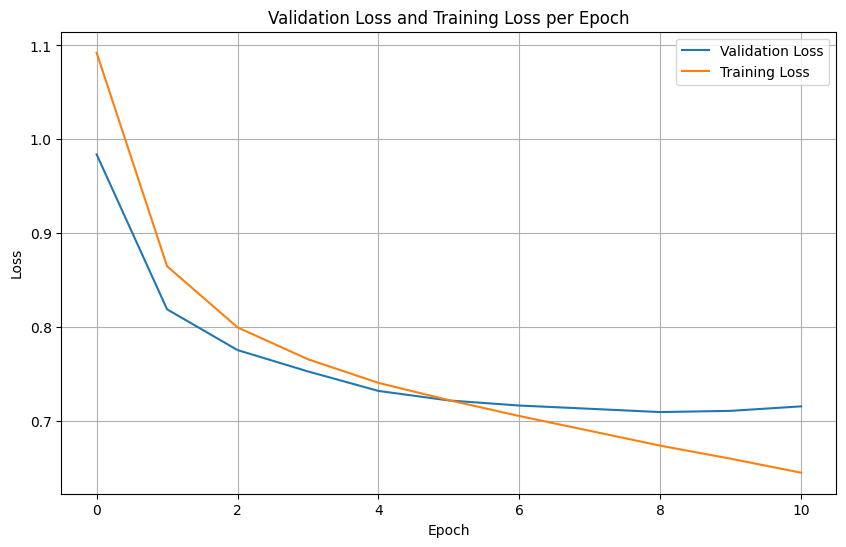

In [329]:
import matplotlib.pyplot as plt
import pandas as pd

metrics = pd.read_csv("../lightning_logs/version_73/metrics.csv")
metrics = metrics[metrics["train_loss_epoch"].notna() + metrics["val_loss"].notna()]
metrics = metrics.groupby("epoch").first()

# metrics = metrics[metrics.index>0]

plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.plot(metrics.index, metrics["val_loss"], label="Validation Loss")
plt.plot(metrics.index, metrics["train_loss_epoch"], label="Training Loss")

# Add labels and title
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss and Training Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [284]:
model = VideoCaptioningDataModule.load_from_checkpoint(
    checkpoint_path="/Users/yann.hallouard/PycharmProjects/personal/lcm-explo/notebooks/data/checkpoints/2025-04-02_22-24-22/epoch=4-step=5500.ckpt",
    model=sonar_context_encoder,
    max_epochs=1,
    batch_size=4,
)
model.eval()

VideoCaptioningDataModule(
  (model): SonarContextEncoder(
    (image_projection): Sequential(
      (0): Linear(in_features=24192, out_features=1024, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.2, inplace=False)
      (3): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (position_embeddings): Embedding(25, 1024)
    (temporal_attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
    )
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(128112, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-23): 24 x M2M100EncoderLayer(
          (self_attn): M2M100SdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_feat

In [285]:
idx = 138
d = val_dataset
batch = d[idx]
captions = d.dataset["captions"][idx]
print(d.dataset["video_path"][idx])

msvd/yg4aNiO1JnI_111_114.avi


In [286]:
batch["target_features"]

tensor([ 0.0074, -0.0023, -0.0071,  ..., -0.0157,  0.0140,  0.0096],
       device='mps:0')

In [287]:
image_features = batch["image_features"].unsqueeze(0).to("mps")
image_features

tensor([[[ 0.0292, -0.0119,  0.0111,  ..., -0.0275, -0.0125, -0.0206],
         [-0.0062,  0.0119, -0.0244,  ..., -0.0069, -0.0116, -0.0126],
         [ 0.0010, -0.0222, -0.0049,  ...,  0.0220, -0.0017,  0.0112],
         ...,
         [-0.0178, -0.0221,  0.0017,  ...,  0.0179,  0.0246, -0.0280],
         [ 0.0154,  0.0100, -0.0170,  ..., -0.0112,  0.0259,  0.0201],
         [ 0.0049, -0.0098, -0.0212,  ..., -0.0118,  0.0111,  0.0063]]],
       device='mps:0')

In [288]:
model.model.to("mps")
embedding = model.model(image_features)
embedding

tensor([[ 0.3306, -0.1536,  0.3651,  ..., -0.0514, -0.1176,  0.0992]],
       device='mps:0', grad_fn=<LinearBackward0>)

In [289]:
from transformers.modeling_outputs import BaseModelOutput

# Decoding into the original (English) language
generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=embedding.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
print(text_out)  # ["My name is SONAR.", "I can embed the sentences into vector space."]

# Decoding into some other (French) language
generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=embedding.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("fra_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
print(text_out)  # ['Mon nom est SONAR.', "Je peux intégrer les phrases dans l'espace vectoriel."]

['( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( (']
['( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( (']


In [290]:
# Decoding into some other (French) language
last_hidden_state = batch["target_features"].unsqueeze(0).unsqueeze(0).detach().to("mps")
generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=last_hidden_state),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("fra_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
print(text_out)  # ['Mon nom est SONAR.', "Je peux intégrer les phrases dans l'espace vectoriel."]

['Un chien joue sur un trampoline']
